In [ ]:
import peft
print(peft.__version__)

0.18.1


In [ ]:
!pip install -q \
  transformers==4.57.3 \
  peft \
  bitsandbytes \
  accelerate \
  datasets \
  loralib \
  sentencepiece

In [ ]:
import torch, transformers, peft, numpy, accelerate, bitsandbytes, numpy


print("torch:", torch.__version__)
print("transformers:", transformers.__version__)
print("peft:", peft.__version__)
print("numpy:", numpy.__version__)
print("accelerate:", accelerate.__version__)
print("bitsandbytes:", bitsandbytes.__version__)
print("numpy:" ,numpy.__version__)

torch: 2.10.0+cu128
transformers: 4.57.3
peft: 0.18.1
numpy: 2.0.2
accelerate: 1.12.0
bitsandbytes: 0.49.2
numpy: 2.0.2


In [ ]:
# Imports
import pandas as pd
import numpy as np
import json
import ast
import torch
import torch.nn as nn
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoConfig,
)
from tqdm import tqdm
import sklearn.metrics
import matplotlib.pyplot as plt



## Load in Model:
Using GPU, this will help us generate faster responses

In [ ]:
# Check if connected to GPU Runtime for generating responses:
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
if torch.cuda.is_available():
  print("GPU name:", torch.cuda.get_device_name(0))

CUDA available: True
CUDA device count: 1
GPU name: NVIDIA A100-SXM4-80GB


In [ ]:
## Load in the MediPhi Model
MODEL_NAME = "microsoft/MediPhi"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
  MODEL_NAME,
  torch_dtype=torch.float16,
  device_map="cuda"
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/2.67G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

## Applying LoRA

Some code I took from this Notebook to Guide me through this

https://colab.research.google.com/drive/14xo6sj4dARk8lXZbOifHEn1f_70qNAwy?usp=sharing#scrollTo=T-gy-LxM0yAi

### Freezing Model Weights

In [ ]:
for param in model.parameters():
  param.requires_grad = False  # freeze the model - train adapters later
  if param.ndim == 1:
    # cast the small parameters (e.g. layernorm) to fp32 for stability
    param.data = param.data.to(torch.float32)

model.gradient_checkpointing_enable()  # reduce number of stored activations
model.enable_input_require_grads()

class CastOutputToFloat(nn.Sequential):
  def forward(self, x): return super().forward(x).to(torch.float32)
model.lm_head = CastOutputToFloat(model.lm_head)

### Setting Up LoRA Adapters

In [ ]:
def print_trainable_parameters(model):
    """
    Prints the number of trainable parameters in the model.
    """
    trainable_params = 0
    all_param = 0
    for _, param in model.named_parameters():
        all_param += param.numel()
        if param.requires_grad:
            trainable_params += param.numel()
    print(f"trainable params: {trainable_params} || all params: {all_param} || trainable%: {100 * trainable_params / all_param}")

In [ ]:
from peft import LoraConfig, get_peft_model, TaskType

config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    target_modules= "all-linear"
)

In [ ]:
model = get_peft_model(model, config)
model.print_trainable_parameters()

trainable params: 12,864,000 || all params: 3,833,943,552 || trainable%: 0.3355


## Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
def convert_label_to_dict(entry: str) -> dict:
    return ast.literal_eval(entry)

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/dsc180/llm_data/data/processed_data_all_entities.csv')
# edema_df
edema_df = data.copy()[['Accession', 'Radiologist_Report', 'Edema', 'Train/Test/Val' ]]
# parse the labels column into dictionaries
edema_df['Edema'] = edema_df['Edema'].apply(convert_label_to_dict)

In [ ]:
# Load prompt
try:
    with open('/content/drive/MyDrive/dsc180/llm_data/data/prompts/Edema_short.txt') as f:
        prompt = f.read()
except:
    print('FileNotFoundError')

In [ ]:
def format_training_strings(report, label, edema_prompt=prompt):
  return f"""
  {edema_prompt}
  {report}
  ### Response:
  {label}
  """.strip()

In [ ]:
edema_df["training_text"] = edema_df.apply(
    lambda row: format_training_strings(
        edema_prompt=prompt,
        report=row["Radiologist_Report"],
        label=row["Edema"],
    ),
    axis=1,
)

In [ ]:
edema_df.iloc[0]['training_text']

'You are a radiologist’s assistant bot. Extract and report structured information related to [pulmonary edema] from the following chest X-ray report.\n\nRespond strictly in the following format. Use only the options listed below. Do not add extra words, explanations, or categories.\n\nReturn your final output as a dictionary with the following keys:\n"Presence", "Severity", and "Change"\nEach key should map to a string.\n\nExample output format:\n{\n"Presence": "present",\n"Severity": "moderate",\n"Change": "increased"\n}\n\nValid options:\n\nPresence:\npresent\nabsent\nunknown\n\nSeverity:\nNA\ntrace\nmild\nmoderate\nsevere\nunknown\n\nChange:\nstable\nincreased\ndecreased\nunknown\nNA\n\nGuidelines:\n\n- If pulmonary edema is explicitly ruled out or the lungs are described as clear, set "Presence" to "absent" and set both "Severity" and "Change" to "NA".\n- Findings such as peribronchial cuffing, Kerley B lines, perihilar opacities, or reticular opacities may suggest edema but are no

In [ ]:
train_df = edema_df[edema_df['Train/Test/Val'] == 'training']
val_df = edema_df[edema_df['Train/Test/Val'] == 'validation']
test_df = edema_df[edema_df['Train/Test/Val'] == 'testing']
print(len(train_df), len(val_df), len(test_df))

500 100 2889


In [ ]:
def tokenize_and_mask(example):
    text = example["training_text"]

    tokenized = tokenizer(
        text,
        truncation=True,
        max_length=2048,
        padding=False,
    )

    input_ids = tokenized["input_ids"]
    labels = input_ids.copy()

    response_marker = "### Response:"
    marker_ids = tokenizer(
        response_marker,
        add_special_tokens=False
    )["input_ids"]

    start_idx = None
    for i in range(len(input_ids) - len(marker_ids) + 1):
        if input_ids[i:i + len(marker_ids)] == marker_ids:
            start_idx = i + len(marker_ids)
            break

    if start_idx is None:
        # Ignore entire example if malformed
        labels = [-100] * len(input_ids)
    else:
        labels[:start_idx] = [-100] * start_idx

    return {
        "input_ids": input_ids,
        "attention_mask": tokenized["attention_mask"],
        "labels": labels,
    }


In [ ]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)

train_dataset = train_dataset.map(
    tokenize_and_mask,
    remove_columns=train_dataset.column_names,
)

val_dataset = val_dataset.map(
    tokenize_and_mask,
    remove_columns=val_dataset.column_names,
)


Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

In [ ]:
train_dataset[0].keys()

dict_keys(['input_ids', 'attention_mask', 'labels'])

## Training

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./mediphi-lora",
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=8,   # effective batch = 16
    learning_rate=2e-4,
    num_train_epochs=3,
    fp16=True,
    logging_steps=20,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    report_to="none",
)

In [ ]:
from transformers import Trainer
from transformers import DataCollatorForSeq2Seq, DataCollatorForLanguageModeling

# 2. Use the Seq2Seq collator
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,        # Passing the model helps it identify the specific pad token IDs
    padding=True,
    label_pad_token_id=-100 # Ensure padding is ignored in loss
)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator= data_collator
)

trainer.train()

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Epoch,Training Loss,Validation Loss
1,0.133900,0.037238
2,0.021000,0.028199
3,0.017800,0.025522


TrainOutput(global_step=96, training_loss=0.044875478371977806, metrics={'train_runtime': 279.4311, 'train_samples_per_second': 5.368, 'train_steps_per_second': 0.344, 'total_flos': 2.222232937511731e+16, 'train_loss': 0.044875478371977806, 'epoch': 3.0})

## Test Inference

In [ ]:
from transformers import AutoTokenizer
from transformers import AutoModelForCausalLM
import torch
from peft import PeftModel

adapter_model_id = "brianthuynh/mediphi-LoRA-Edema"
tokenizer = AutoTokenizer.from_pretrained("microsoft/MediPhi")
base_model = AutoModelForCausalLM.from_pretrained(
    "microsoft/MediPhi",
    torch_dtype=torch.float16,
)

tuned_model = PeftModel.from_pretrained(base_model, adapter_model_id)
tuned_model.to("cuda")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Phi3ForCausalLM(
      (model): Phi3Model(
        (embed_tokens): Embedding(32064, 3072, padding_idx=32000)
        (layers): ModuleList(
          (0-31): 32 x Phi3DecoderLayer(
            (self_attn): Phi3Attention(
              (o_proj): lora.Linear(
                (base_layer): Linear(in_features=3072, out_features=3072, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=3072, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=3072, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (qkv_proj

In [ ]:
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

CUDA available: True
CUDA device count: 1
GPU name: NVIDIA A100-SXM4-80GB


In [ ]:
def ask_llm_batch(reports, prompt, model=tuned_model):
    messages = [
        [{"role": "user", "content": prompt + report}]
        for report in reports
    ]

    inputs = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
        padding=True,
    )

    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=40,
            do_sample=False,
        )

    decoded = tokenizer.batch_decode(
        outputs[:, inputs["input_ids"].shape[-1]:],
        skip_special_tokens=True,
    )

    # CLEAR UNUSED CUDA MEMORY
    del inputs, outputs
    torch.cuda.empty_cache()

    return [(d) for d in decoded]


In [ ]:
def make_predictions(prompt, df: pd.DataFrame, BATCH_SIZE: int):
    results = []

    total = len(df)
    for i in tqdm(
        range(0, total, BATCH_SIZE),
        desc="Running LLM inference",
        unit="reports",
    ):
        batch_reports = df["Radiologist_Report"].iloc[i:i + BATCH_SIZE].tolist()
        batch_results = ask_llm_batch(batch_reports, prompt)
        results.extend(batch_results)

    return results

In [ ]:
predictions_out = make_predictions(prompt, test_df, 50)

Running LLM inference: 100%|██████████| 58/58 [05:46<00:00,  5.98s/reports]


In [ ]:
import ast
import re

def extract_response_dict(text: str) -> dict | None:
    """
    Extracts the first Python-style dictionary from a model response string.

    Returns:
        dict if successful
        None if extraction or parsing fails
    """
    if not isinstance(text, str):
        return None

    # Match the first {...} block (non-greedy)
    match = re.search(r"\{.*?\}", text, re.DOTALL)

    if not match:
        return None

    dict_str = match.group(0)

    try:
        # Safely parse Python literal
        return ast.literal_eval(dict_str)
    except (SyntaxError, ValueError):
        return None


In [ ]:
clean_pred_out = [extract_response_dict(txt) for txt in predictions_out]
test_df['llm_predictions'] = clean_pred_out

/tmp/ipython-input-3312361243.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['llm_predictions'] = clean_pred_out


## Evaluating Responses

In [ ]:
evalulate_cols = ['Edema', 'llm_predictions']
expanded_edema_df = pd.concat(
    [
        pd.json_normalize(test_df[col]).add_prefix(f"{col}_")
        for col in evalulate_cols
    ],
    axis=1
)

In [ ]:
expanded_edema_df.head()

,Edema_Presence,Edema_Severity,Edema_Change,llm_predictions_Presence,llm_predictions_Severity,llm_predictions_Change
0,present,moderate,stable,present,unknown,unknown
1,unknown,unknown,unknown,absent,NA,NA
2,absent,NA,NA,absent,NA,NA
3,unknown,unknown,stable,absent,NA,NA
4,present,mild,unknown,present,mild,unknown


In [ ]:
def map_results_for_prescence(label: str) -> str:
  LABEL_MAP = {
    # ABSENT
    "absent": "absent",
    "none": "absent",
    "no": "absent",
    "without": "absent",

    # PRESENT (positive edema)
    "present": "present",
    "mild": "present",
    "minimal": "present",
    "trace": "present",
    "borderline": "present",
    "possible": "present",
    "possible mild": "present",

    # UNCERTAIN
    "unknown": "unknown",
    "na": "unknown",
    "n/a": "unknown",
    "uncertain": "unknown"
  }
  if label is None:
    return 'unknown'
  raw_label = label.lower().strip()
  if raw_label in LABEL_MAP:
    return LABEL_MAP[raw_label]

expanded_edema_df['llm_predictions_Presence'] = expanded_edema_df['llm_predictions_Presence'].apply(map_results_for_prescence)
expanded_edema_df['Edema_Presence'] = expanded_edema_df['Edema_Presence'].apply(map_results_for_prescence)

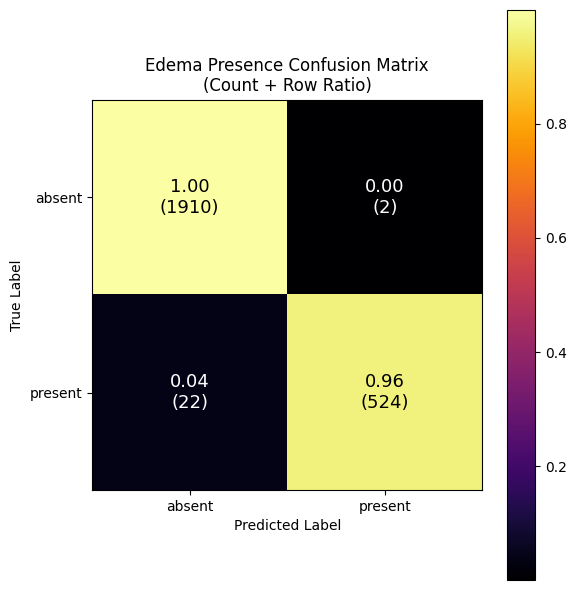

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Remove unknowns
filtered_df = expanded_edema_df[
    (expanded_edema_df['Edema_Presence'] != 'unknown') &
    (expanded_edema_df['llm_predictions_Presence'] != 'unknown')
]

# Raw counts
cm_counts = confusion_matrix(
    filtered_df['Edema_Presence'],
    filtered_df['llm_predictions_Presence'],
    labels=['absent', 'present']
)

# Row ratios
cm_ratio = cm_counts / cm_counts.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6,6))
im = ax.imshow(cm_ratio, cmap='inferno')

# Threshold for switching text color
threshold = 0.5

for i in range(cm_counts.shape[0]):
    for j in range(cm_counts.shape[1]):
        ax.text(
            j, i,
            f"{cm_ratio[i, j]:.2f}\n({cm_counts[i, j]})",
            ha="center",
            va="center",
            fontsize=13,
            color="white" if cm_ratio[i, j] < threshold else "black"
        )

ax.set_xticks([0,1])
ax.set_yticks([0,1])
ax.set_xticklabels(['absent','present'])
ax.set_yticklabels(['absent','present'])

ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title("Edema Presence Confusion Matrix\n(Count + Row Ratio)")

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

In [ ]:
print(expanded_edema_df['Edema_Severity'].unique())
print(50 * '=')
print(expanded_edema_df['llm_predictions_Severity'].unique())
['mild' ,'moderate', 'unknown', 'severe', 'trace']

['moderate' 'unknown' 'NA' 'mild' 'trace' 'severe']
['unknown' 'NA' 'mild' 'moderate' 'trace' 'severe']


['mild', 'moderate', 'unknown', 'severe', 'trace']

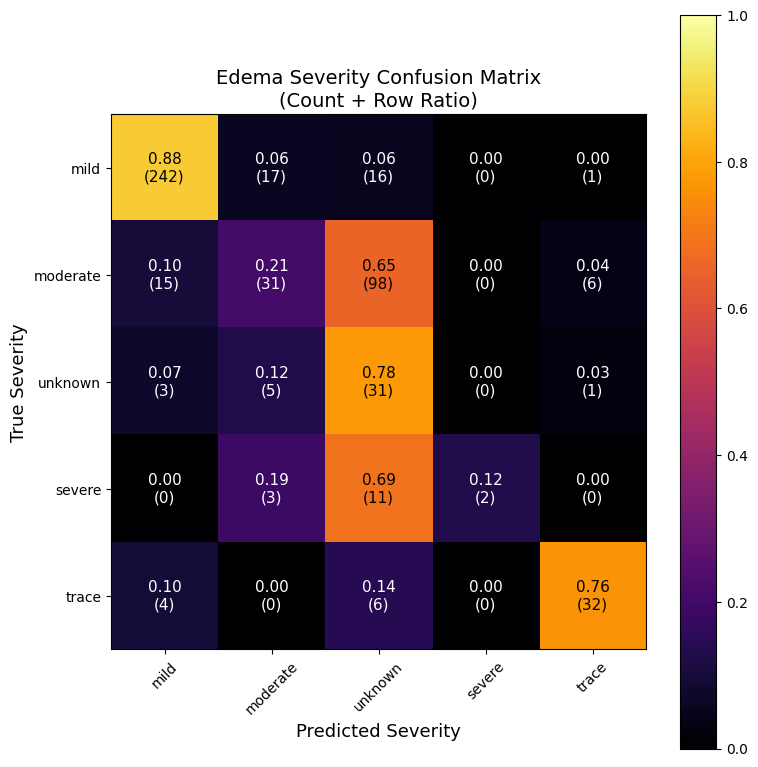

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
labels_lst = ['mild' ,'moderate', 'unknown', 'severe', 'trace']
# Raw counts
cm_counts = confusion_matrix(
    filtered_df['Edema_Severity'],
    filtered_df['llm_predictions_Severity'],
    labels= labels_lst
)

# Row ratios
cm_ratio = cm_counts / cm_counts.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(8,8))
im = ax.imshow(cm_ratio, cmap="inferno", vmin=0, vmax=1)

# Dynamic text color threshold
threshold = 0.5

for i in range(len(labels_lst)):
    for j in range(len(labels_lst)):
        color = "white" if cm_ratio[i, j] < threshold else "black"
        ax.text(
            j, i,
            f"{cm_ratio[i, j]:.2f}\n({cm_counts[i, j]})",
            ha="center",
            va="center",
            fontsize=11,
            color=color
        )

ax.set_xticks(range(len(labels_lst)))
ax.set_yticks(range(len(labels_lst)))
ax.set_xticklabels(labels_lst, rotation=45)
ax.set_yticklabels(labels_lst)

ax.set_xlabel("Predicted Severity", fontsize=13)
ax.set_ylabel("True Severity", fontsize=13)
ax.set_title("Edema Severity Confusion Matrix\n(Count + Row Ratio)", fontsize=14)

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

In [ ]:
from huggingface_hub import login
login()